# Creating Meshes

This tutorial demonstrates how to build a mesh from an existing reconstruction using the `Splatter` wrapper.
TSDF fusion integrates depth and normals into a volumetric grid; Poisson reconstruction converts that into a watertight surface.
The resulting mesh carries per-vertex semantic feature vectors that can be queried with text prompts — without reloading the full model.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import copy
import os
from pathlib import Path

import numpy as np
import open3d as o3d
import pyvista as pv
%matplotlib inline

# Use static backend in headless CI; interactive trame otherwise
pv.set_jupyter_backend("static" if os.environ.get("PYVISTA_OFF_SCREEN") else "trame")

from collab_splats.mesh.utils import mesh_clustering
from collab_splats.wrapper import Splatter, SplatterConfig

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


/opt/conda/envs/nerfstudio/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/opt/conda/envs/nerfstudio/lib/python3.11/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/opt/conda/envs/nerfstudio/lib/python3.11/site-packages/mobile_sam/modeling/tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_5m_224 in registry with mobile_sam.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
/opt/conda/envs/nerfstudio/lib/python3.11/site-packages/mobile_sam/mod

/workspace/nerfstudio/nerfstudio/field_components/activations.py:32: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=torch.float32)
/workspace/nerfstudio/nerfstudio/field_components/activations.py:38: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd


## §1 — Configuration

In [3]:
%run ../tutorial_config.py

########################################################################
# Configuration
########################################################################
METHOD  = "rade-features"

BASE_DIR     = Path("/workspace/fieldwork-data/")
SESSION_DIR  = BASE_DIR / "birds/2024-02-06/SplatsSD"
VIDEO_FILE   = SESSION_DIR / "C0043.MP4"

# Build Splatter config and initialize wrapper
splatter_config = SplatterConfig(
    file_path=VIDEO_FILE,
    method=METHOD,
    frame_proportion=0.25,  # use 25% of frames (minimum 300)
)
splatter = Splatter(splatter_config)

# Populate splatter with preprocessed paths (no-ops if outputs already exist)
splatter.preprocess()
splatter.extract_features()

transforms.json already exists at /workspace/fieldwork-data/birds/2024-02-06/environment/C0043/preproc/transforms.json
To rerun preprocessing, set overwrite=True
Output already exists for rade-features
To rerun feature extraction, set overwrite=True


## §2 — TSDF Mesh Creation

`splatter.mesh()` runs Open3D TSDF fusion over the depth/normals rendered by the nerfstudio model, then cleans and aligns the resulting surface.
The call is idempotent — pass `overwrite=True` to re-run.

In [4]:
mesher_kwargs = {
    "depth_name": "median_depth",
    "depth_trunc": 1.0,  # Should be between 1.0 and 3.0
    "voxel_size": 0.005,
    "normals_name": "normals",
    "features_name": "distill_features",
    "sdf_trunc": 0.03,
    "clean_repair": True,
    "align_floor": True,
}

splatter.mesh(
    mesher_type="Open3DTSDFFusion",
    mesher_kwargs=mesher_kwargs,
    # overwrite=True
)


Available runs:
[0] 2026-04-29_021745


## §3 — Saved Outputs

After `mesh()`, the following files are written to `{output_path}/{method}/mesh/`:

| File | Description |
|---|---|
| `mesh_tsdf_clean.ply` | Mesh geometry |
| `mesh_features.pt` | Per-vertex latent feature vectors |
| `mesh_decoder.pt` | MLP decoder weights — enables model-free querying |
| `splats.ply` | Gaussian positions + colours |

In [5]:
mesh_dir = splatter.config["mesh_info"]["mesh"].parent
for f in sorted(mesh_dir.iterdir()):
    size_kb = f.stat().st_size // 1024
    print(f"  {f.name:<40s}  {size_kb:>6d} KB")

  mesh_decoder.pt                              298 KB
  mesh_features.pt                             591 KB
  mesh_tsdf.ply                                457 KB
  mesh_tsdf_clean.ply                          570 KB
  query-feeder.ply                             570 KB
  query-ground.ply                             570 KB
  query-sky.ply                                570 KB
  query-tree.ply                               570 KB
  splats.ply                                122454 KB


## §4 — Visualising the Mesh

`plot_mesh()` accepts `attribute="RGB"` or `attribute="Normals"` for geometry inspection,
or a per-vertex similarity array returned by `query_mesh()`.

Number of points: 11623
Number of cells: 20775
Bounds: BoundsTuple(x_min = -0.9780185222625732,
            x_max =  0.7099999785423279,
            y_min = -0.27000001072883606,
            y_max =  1.25,
            z_min = -0.21421033143997192,
            z_max =  0.5899999737739563)


2026-05-23 08:38:48.071 (  49.044s) [    740004E46740]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


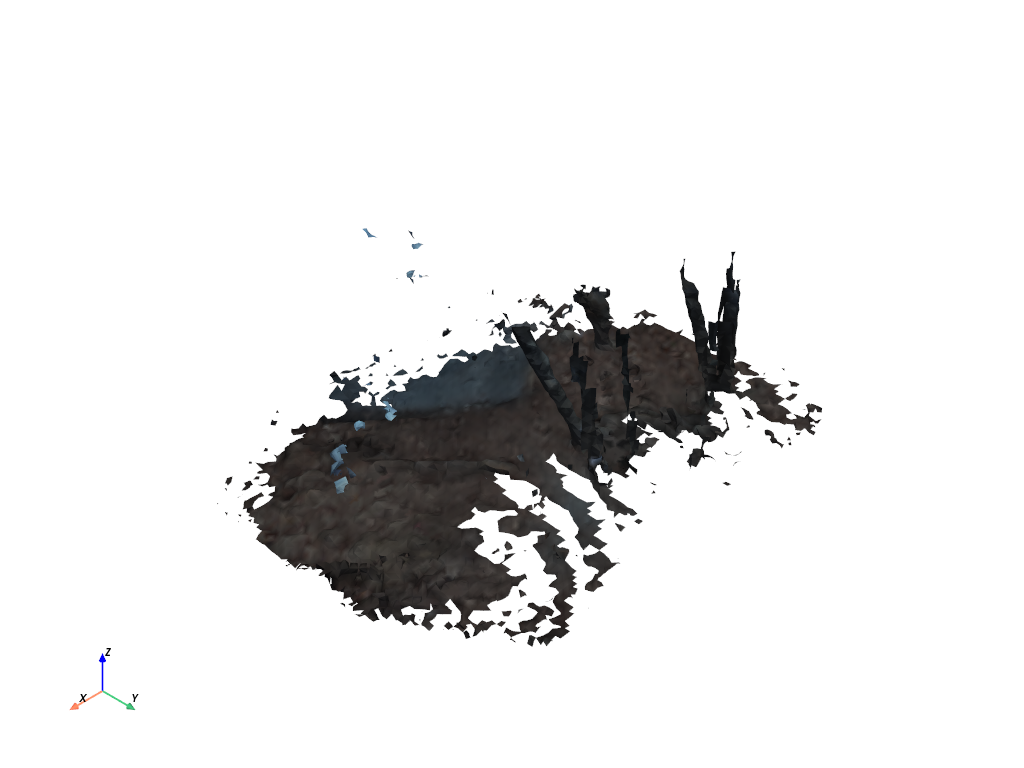

In [6]:
splatter.plot_mesh(attribute="RGB")

## §5 — Semantic Queries via `query_mesh`

The mesh carries per-vertex semantic features queryable with text prompts.
`query_mesh()` uses the saved `mesh_decoder.pt` — **the full nerfstudio model is not reloaded**.
Subsequent calls, and calls from a fresh Python session (after `mesh(overwrite=False)`), skip `eval_setup` entirely.

In [7]:
similarity = splatter.query_mesh(
    positive_queries=["feeder"], negative_queries=["ground", "leaves", "rocks"], output_fn="query-feeder.ply"
)

/workspace/collab-splats/collab_splats/wrapper/splatter.py:626: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  features = torch.load(self.config["mesh_info"]["features"])


Plot similarity map — brighter = higher match to the positive query.

Number of points: 11623
Number of cells: 20775
Bounds: BoundsTuple(x_min = -0.9780185222625732,
            x_max =  0.7099999785423279,
            y_min = -0.27000001072883606,
            y_max =  1.25,
            z_min = -0.21421033143997192,
            z_max =  0.5899999737739563)


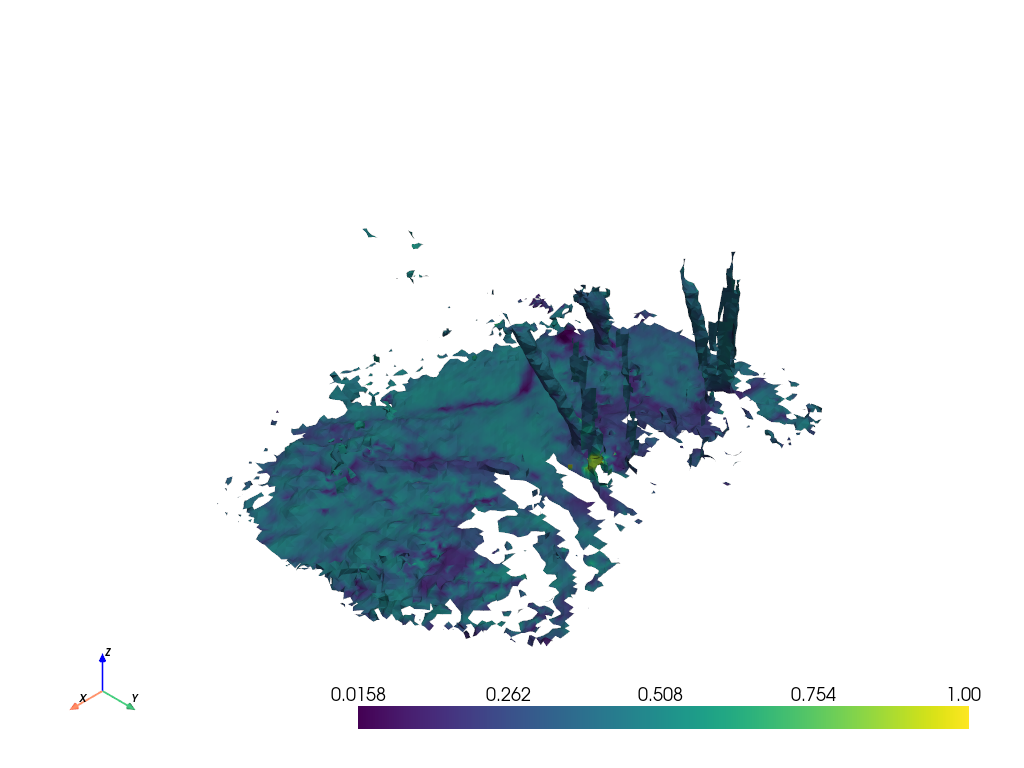

In [8]:
splatter.plot_mesh(attribute=similarity, rgb=False)

## §6 — Semantic Clustering

Connected-component clustering isolates spatially coherent high-similarity regions.
Threshold and radius control which vertices are considered "activated".

In [9]:
# Load the saved query mesh and extract per-vertex similarity values
mesh_dir = splatter.config["mesh_info"]["mesh"].parent
query_mesh_path = mesh_dir / "query-feeder.ply"
mesh = o3d.io.read_triangle_mesh(str(query_mesh_path))
similarity_vals = np.asarray(mesh.vertex_colors)[:, 0]

print(f"Similarity range: [{similarity_vals.min():.3f}, {similarity_vals.max():.3f}]  "
      f"p90={np.percentile(similarity_vals, 90):.3f}")

# Cluster vertices by similarity threshold + spatial proximity
clusters = mesh_clustering(
    mesh=mesh,
    similarity_values=similarity_vals,
    similarity_threshold=0.7,
    spatial_radius=0.05,
)
print(f"Clusters found: {len(clusters)}  (sizes: {sorted([len(c) for c in clusters], reverse=True)[:5]})")

Similarity range: [0.016, 1.000]  p90=0.455


Building adjacency matrix: 0it [00:00, ?it/s]

Building adjacency matrix: 61it [00:00, 7278.46it/s]

Clusters found: 1  (sizes: [47])


Select and highlight the largest cluster.

In [10]:
# Get sizes of each cluster; sort descending to find the largest
cluster_sizes = [x.shape[0] for x in clusters]
cluster_size_idxs = np.argsort(cluster_sizes)[::-1]

# Extract vertex indices of the largest cluster
target_cluster = clusters[cluster_size_idxs[0]]
cluster_vertices = np.array(target_cluster)

# Build per-vertex color array: black background, red for selected cluster
colors = np.zeros((len(mesh.vertices), 3))
colors[cluster_vertices] = [1, 0, 0]

Write cluster mesh to disk, then visualise.

In [11]:
# Deep-copy the mesh to avoid mutating the original, then assign cluster colors
cluster_mesh = copy.deepcopy(mesh)
cluster_mesh.vertex_colors = o3d.utility.Vector3dVector(colors)

# Save annotated mesh alongside the query mesh
o3d.io.write_triangle_mesh(str(mesh_dir / "query-feeder_top-cluster.ply"), cluster_mesh)

True

Plot the top cluster (red vertices on black background).

Number of points: 11623
Number of cells: 20775
Bounds: BoundsTuple(x_min = -0.9780185222625732,
            x_max =  0.7099999785423279,
            y_min = -0.27000001072883606,
            y_max =  1.25,
            z_min = -0.21421033143997192,
            z_max =  0.5899999737739563)


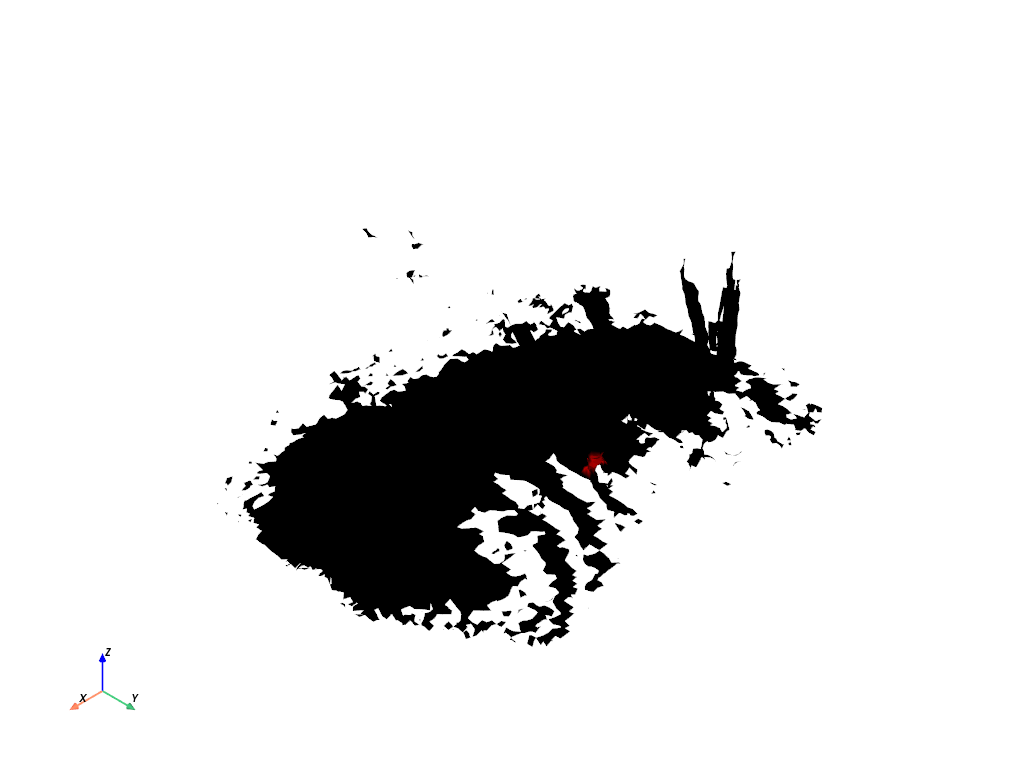

In [12]:
splatter.plot_mesh(colors)

## §7 — Querying from a Fresh Session

Because `mesh_decoder.pt` is saved alongside the mesh, semantic queries run **without reloading the nerfstudio model**.
Create a new `Splatter`, call `mesh(overwrite=False)` to load existing outputs, then call `query_mesh()`.

In [13]:
# Fresh session — no extract_features() needed; loads saved mesh_decoder.pt
splatter_reload = Splatter(splatter_config)
splatter_reload.mesh(overwrite=False)

# Query without reloading the nerfstudio model
similarity_fresh = splatter_reload.query_mesh(
    positive_queries=["feeder"],
    negative_queries=["ground", "leaves", "rocks"],
)
print(f"Shape:            {similarity_fresh.shape}")
print(f"Similarity range: [{similarity_fresh[:, 0].min():.3f}, {similarity_fresh[:, 0].max():.3f}]")


Available runs:
[0] 2026-04-29_021745


Shape:            (11623, 3)
Similarity range: [0.016, 1.000]
